<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

----

###  Regresión Logística con Python y Scikit-Learn

#### Contenidos
1. Regresión Logística
   - Introducción
   - Implementación en Python
   - Interpretación de Resultados
   - Métricas de Desempeño



In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification



#  2. Regresión Logística

#### Introducción
La regresión logística es una técnica utilizada para modelar la probabilidad de un evento binario. A diferencia de la regresión lineal, la salida es una variable categórica.

#### Implementación en Python

**Paso 1: Importar las bibliotecas necesarias**



### Paso 1: Crear el Conjunto de Datos Artificial

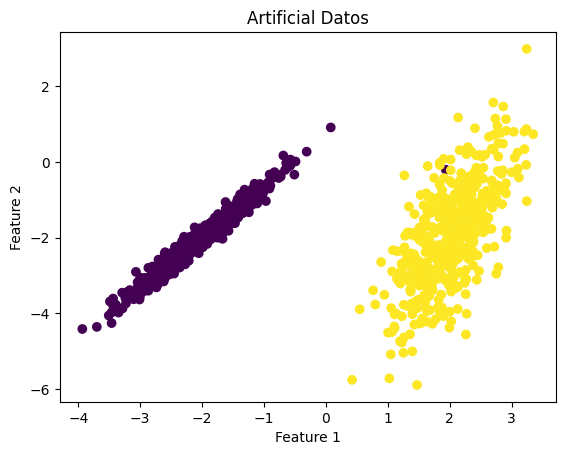

In [58]:
# Crear un conjunto de datos artificial
X, y = make_classification(n_samples=1000, 
                           n_features=2, 
                           n_informative=2, 
                           n_redundant=0, 
                           n_clusters_per_class=1, 
                           class_sep=2, random_state=4)

# Visualizar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Artificial Datos')
plt.show()


### Paso 2: Separar los Datos en Entrenamiento y Prueba

In [68]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Paso 3: Entrenar el Modelo de Regresión Logística

In [69]:
# Entrenar el modelo
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [52]:
model.coef_


array([[ 3.13974382, -1.14905526]])

In [7]:
model.intercept_

array([-2.44337045])

In [70]:
X

array([[ 2.22515974, -1.95173116],
       [ 2.01630365, -2.72517506],
       [ 1.33534004, -2.7248955 ],
       ...,
       [ 2.54270795, -1.05566478],
       [ 1.81664566, -2.2509187 ],
       [ 2.13782254, -2.26151957]])

### Paso 4: Hacer Predicciones y Calcular Métricas de Desempeño

In [53]:
probabilidades = model.predict_proba(X_test)
probabilidades[:10]

array([[9.98229490e-01, 1.77050976e-03],
       [9.96716216e-01, 3.28378369e-03],
       [4.32912431e-04, 9.99567088e-01],
       [1.05525481e-02, 9.89447452e-01],
       [7.49007791e-03, 9.92509922e-01],
       [9.97883042e-01, 2.11695804e-03],
       [6.23121006e-04, 9.99376879e-01],
       [9.98168243e-01, 1.83175675e-03],
       [9.81845177e-01, 1.81548230e-02],
       [9.99034095e-01, 9.65904946e-04]])

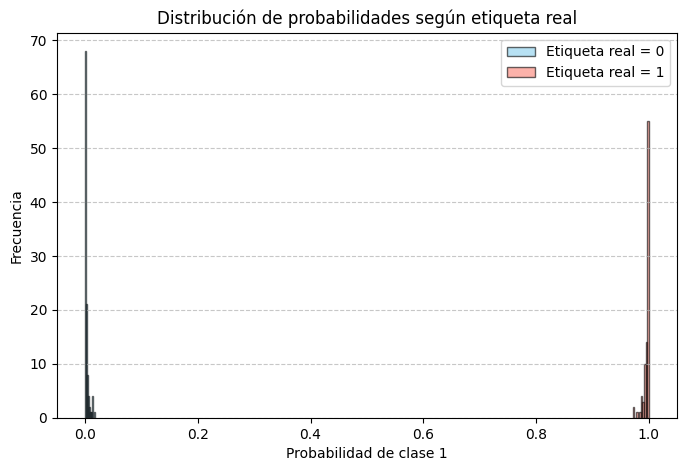

In [55]:
# Filtrar probabilidades según la clase real
prob_clase0 = probabilidades[y_test == 0,1]
prob_clase1 = probabilidades[y_test == 1,1]

# Graficar histogramas en la misma figura
plt.figure(figsize=(8,5))
plt.hist(prob_clase0, bins=10, alpha=0.6, label="Etiqueta real = 0", color="skyblue", edgecolor="black")
plt.hist(prob_clase1, bins=10, alpha=0.6, label="Etiqueta real = 1", color="salmon", edgecolor="black")

plt.xlabel("Probabilidad de clase 1")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades según etiqueta real")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [71]:
score = probabilidades[:,1]
score>0.5

array([False, False,  True,  True,  True, False,  True, False, False,
       False,  True, False, False,  True, False, False, False,  True,
       False, False,  True,  True,  True,  True, False,  True,  True,
       False, False,  True,  True, False, False,  True, False,  True,
        True, False, False,  True, False, False,  True,  True,  True,
       False,  True, False, False, False,  True,  True, False,  True,
       False,  True,  True, False, False, False,  True,  True, False,
       False, False, False,  True,  True,  True,  True, False,  True,
       False, False,  True, False, False, False, False,  True, False,
        True,  True, False, False,  True,  True, False, False,  True,
       False, False, False,  True,  True,  True, False, False,  True,
        True, False, False, False, False, False, False,  True, False,
        True, False, False, False, False,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True, False, False,  True,
       False, False,

In [8]:
# Hacer predicciones
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0])

In [9]:
sum(y_test==y_pred)/y_test.size

np.float64(1.0)

In [11]:
# Calcular métricas de desempeño
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 1.0
Confusion Matrix:
[[110   0]
 [  0  90]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        90

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



#### Interpretación de Métricas

- **Exactitud**: Proporción de predicciones correctas sobre el total de predicciones.
- **Matriz de Confusión**: Tabla que muestra las verdaderas etiquetas vs. las predicciones del modelo.
- **Reporte de Clasificación**: Incluye métricas como precisión, recall y F1-score.
- **Precisión**: Proporción de verdaderos positivos entre todos los positivos predichos.
- **Recall (Sensibilidad)**: Proporción de verdaderos positivos entre todos los positivos reales.
- **F1-score**: Media armónica de la precisión y el recall.


### Paso 5: Mostrar la Frontera de Decisión

**NOTA IMPORTANTE**: este proceso solo aplica cuando trabajamos con datos en 2D

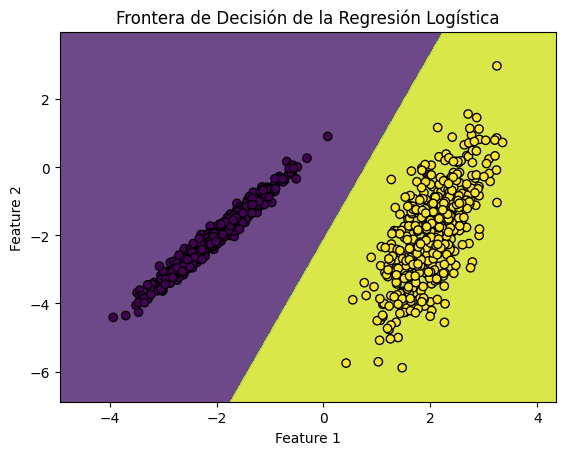

In [14]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# Predecir las clases para cada punto en la malla
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Visualizar los datos y la frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Frontera de Decisión de la Regresión Logística')
plt.show()

## Ejercicio 1:

Explorar regresión logistica con una base de datos real:
La base de datos "Pima Indian Diabetes" es un conjunto de datos muy utilizado en el ámbito del aprendizaje automático para practicar y desarrollar modelos de clasificación, específicamente para predecir la presencia de diabetes en pacientes con base en ciertas medidas diagnósticas.

In [23]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Cargar dataset Pima Indians Diabetes
data = fetch_openml(name="diabetes", version=1, as_frame=True)

# Convertir a DataFrame
df = data.frame
column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df.columns = column_names

df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


In [15]:
print(df.info())
print(df["Outcome"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Pregnancies               768 non-null    int64   
 1   Glucose                   768 non-null    int64   
 2   BloodPressure             768 non-null    int64   
 3   SkinThickness             768 non-null    int64   
 4   Insulin                   768 non-null    int64   
 5   BMI                       768 non-null    float64 
 6   DiabetesPedigreeFunction  768 non-null    float64 
 7   Age                       768 non-null    int64   
 8   Outcome                   768 non-null    category
dtypes: category(1), float64(2), int64(6)
memory usage: 49.0 KB
None
Outcome
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [16]:
# Usando map
df["Outcome"] = df["Outcome"].map({
    "tested_negative": 0,
    "tested_positive": 1
})

print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [17]:
# Estadísticas descriptivas
print(df.describe())

# Comprobar valores nulos
print(df.isnull().sum())


       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age  
count  768.000000                768.000000  768.000000  
mean    31.992578                  0.471876   33.240885  
std      7.884160                  0.331329   11.760232  
min      0.000000                  0.078000   21.000000  
25%     27.300000        


###  2: Preparar los Datos

1. **Dividir los datos en características (X) y etiquetas (y)**.



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir en características (X) y etiquetas (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 3: Entrenar el Modelo de Regresión Logística

1. **Entrenar el modelo**: Utiliza `LogisticRegression` para entrenar el modelo en el conjunto de entrenamiento.
2. **Evaluar el modelo**: Evalúa el modelo en el conjunto de prueba utilizando métricas como precisión, recall, y la matriz de confusión.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
scaler = StandardScaler()
# Entrenar el modelo
model = LogisticRegression(max_iter=10000)

# Normalizar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#entrenar
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

Accuracy: 0.7532467532467533
Confusion Matrix:
[[79 20]
 [18 37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



###  5: Interpretación de Resultados

1. **Coeficientes del modelo**: Analiza los coeficientes del modelo para entender la importancia de cada característica.
2. **Visualización**: Utiliza gráficos para visualizar la relación entre las características más importantes y la probabilidad de diabetes.

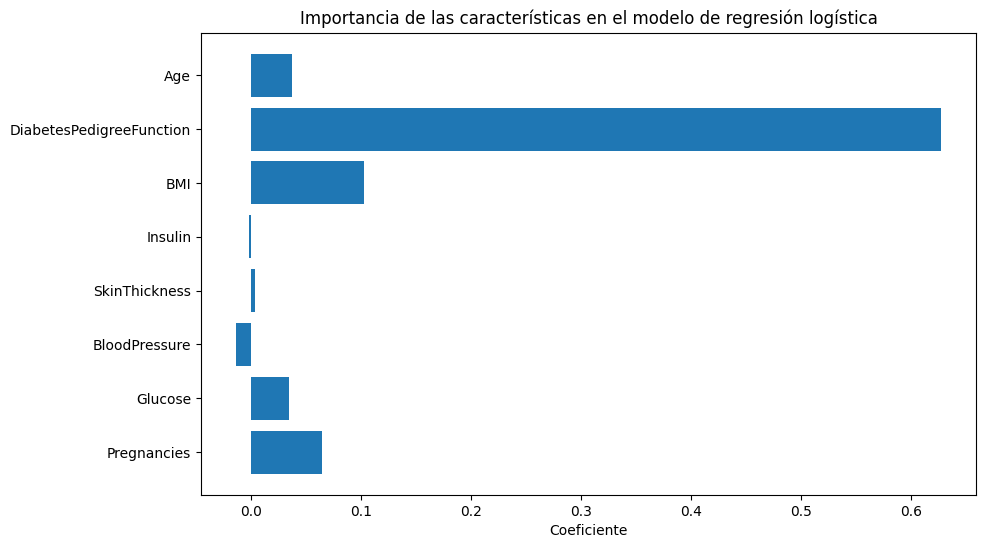

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Coeficientes del modelo
coefficients = model.coef_[0]
features = column_names[:-1]#X_train.columns

# Visualizar los coeficientes
plt.figure(figsize=(10, 6))
plt.barh(features, coefficients)
plt.xlabel('Coeficiente')
plt.title('Importancia de las características en el modelo de regresión logística')
plt.show()

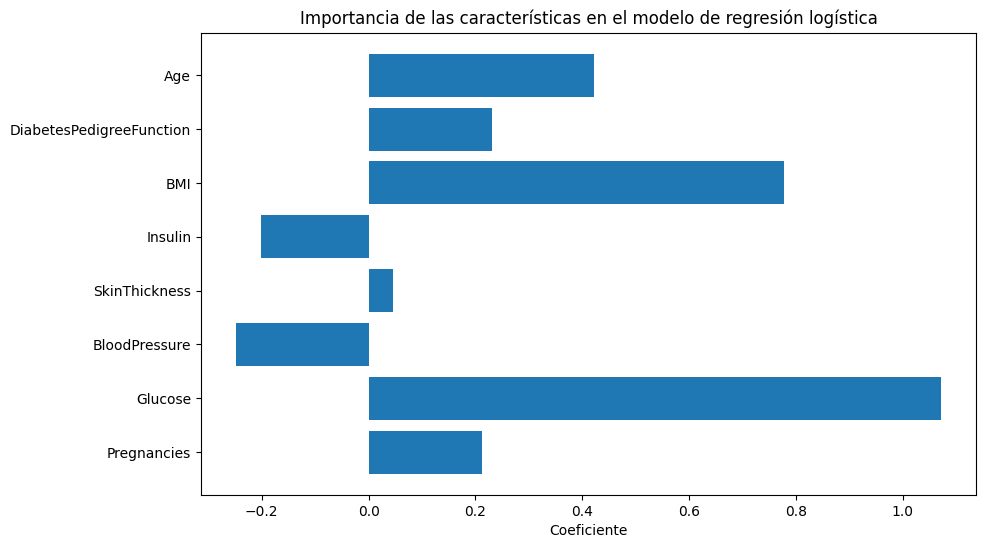

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Coeficientes del modelo
coefficients = model.coef_[0]
features = column_names[:-1]#X_train.columns

# Visualizar los coeficientes
plt.figure(figsize=(10, 6))
plt.barh(features, coefficients)
plt.xlabel('Coeficiente')
plt.title('Importancia de las características en el modelo de regresión logística')
plt.show()

In [86]:
column_names[:-1]

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

# Que hacer cuando tenemos variables categoricas?

### Conjunto de Datos en Formato CSV

In [39]:
import pandas as pd

# Crear el DataFrame a partir del archivo CSV
data = pd.read_csv('data/users.csv')

# Mostrar el DataFrame original
print("DataFrame Original:")
data.head()

DataFrame Original:


,ID,Genero,Estado Civil,Ocupacion,Ingreso_Anual_(USD)
0,1,M,Soltero,Ingeniero,75000
1,2,F,Casado,Médico,120000
2,3,F,Soltero,Abogado,90000
3,4,M,Casado,Ingeniero,80000
4,5,M,Soltero,Maestro,50000


In [144]:
data["Ocupacion"].value_counts()

Ocupacion
Ingeniero    5
Médico       4
Abogado      4
Maestro      4
Enfermera    3
Name: count, dtype: int64

### Transformar las Variables Categóricas

In [92]:
data_dummies = pd.get_dummies(data, columns=['Genero', 'Estado Civil', 'Ocupacion'], drop_first=True)

# Mostrar el DataFrame con variables dummy
print("\nDataFrame con Variables Dummy:")
data_dummies.head()


DataFrame con Variables Dummy:


,ID,Ingreso_Anual_(USD),Genero_M,Estado Civil_Soltero,Ocupacion_Enfermera,Ocupacion_Ingeniero,Ocupacion_Maestro,Ocupacion_Médico
0,1,75000,True,True,False,True,False,False
1,2,120000,False,False,False,False,False,True
2,3,90000,False,True,False,False,False,False
3,4,80000,True,False,False,True,False,False
4,5,50000,True,True,False,False,True,False


## Ejercicio

Los datos están relacionados con campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. El objetivo de la clasificación es predecir si el cliente suscribirá un depósito a plazo fijo (variable y).

Los datos se pueden descargar de la siguiente página y tambien se pueden consultar detalles adicionales

**https://archive.ics.uci.edu/dataset/222/bank+marketing**



In [18]:
df = pd.read_csv('RUTA A LOS DATOS/bank-full.csv', sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [19]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

**Tratar las variables categoricas**

In [20]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features 

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [21]:
df = pd.get_dummies(df, columns=categorical_features, drop_first=True) 

In [22]:
# rename the y_yes column to y
df.rename(columns={'y_yes': 'y'}, inplace=True) 

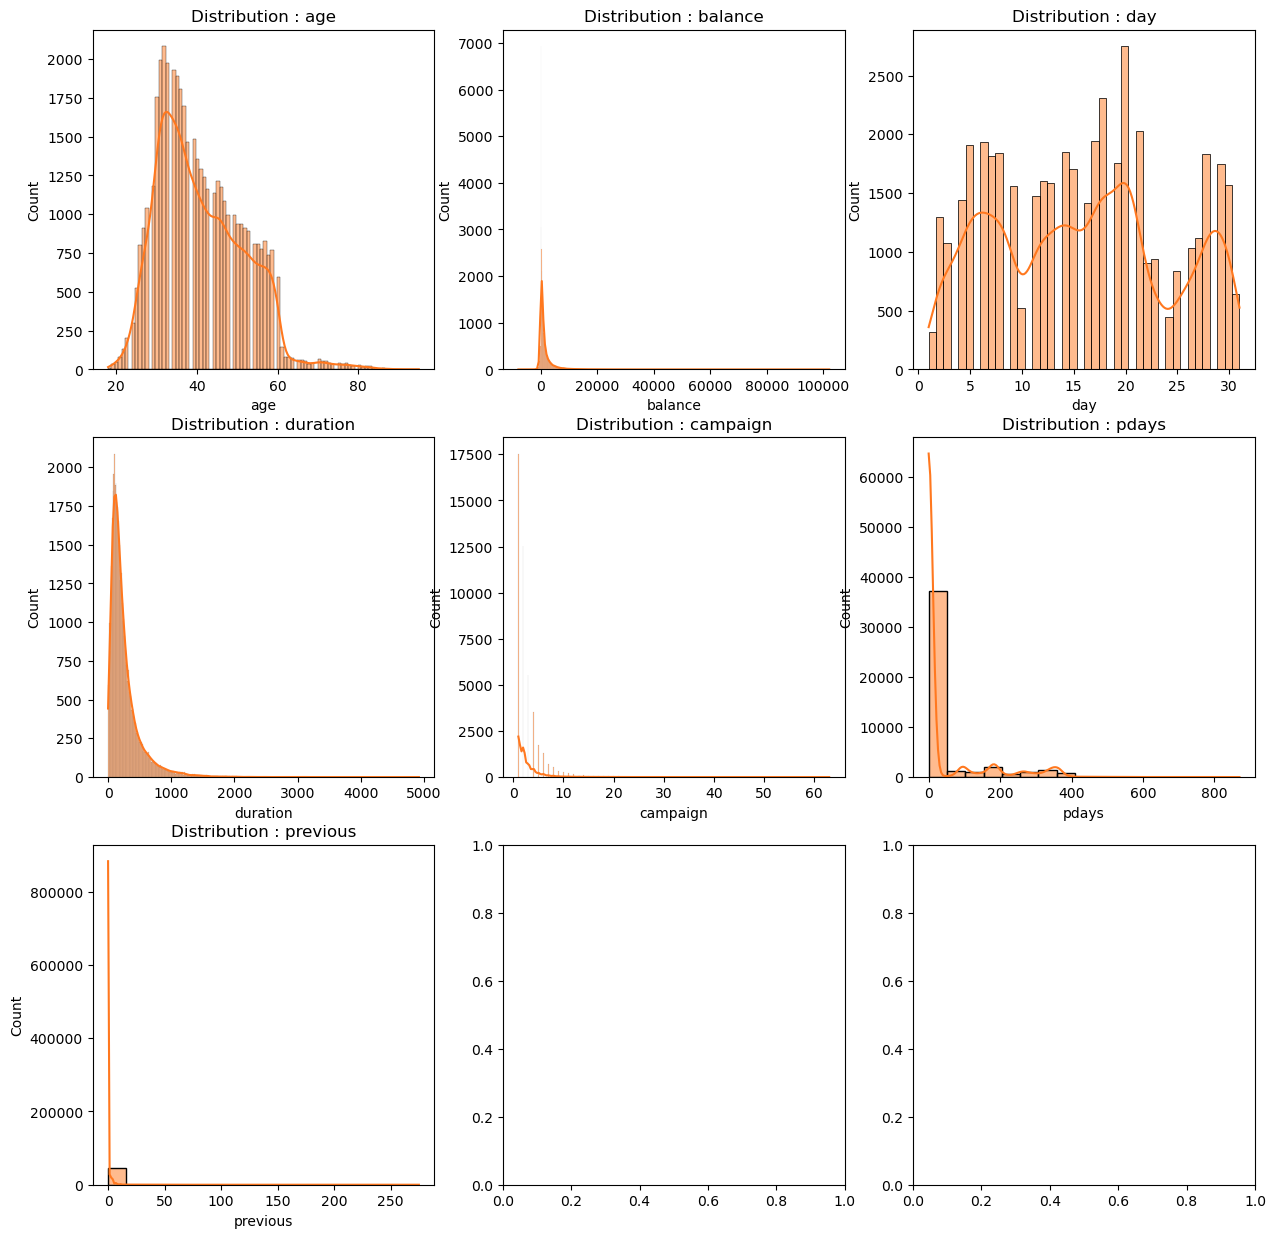

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_features = df.select_dtypes(include=['int64']).columns
colors = ['#FF781F','#2D2926']

fig, ax = plt.subplots(nrows = 3,ncols = 3,figsize = (15,15))
for i in range(len(numerical_features)):
    plt.subplot(3,3,i+1)
    sns.histplot(df[numerical_features[i]],color = colors[0],kde=True)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

In [24]:
X = df.drop('y', axis=1)
y = df['y']

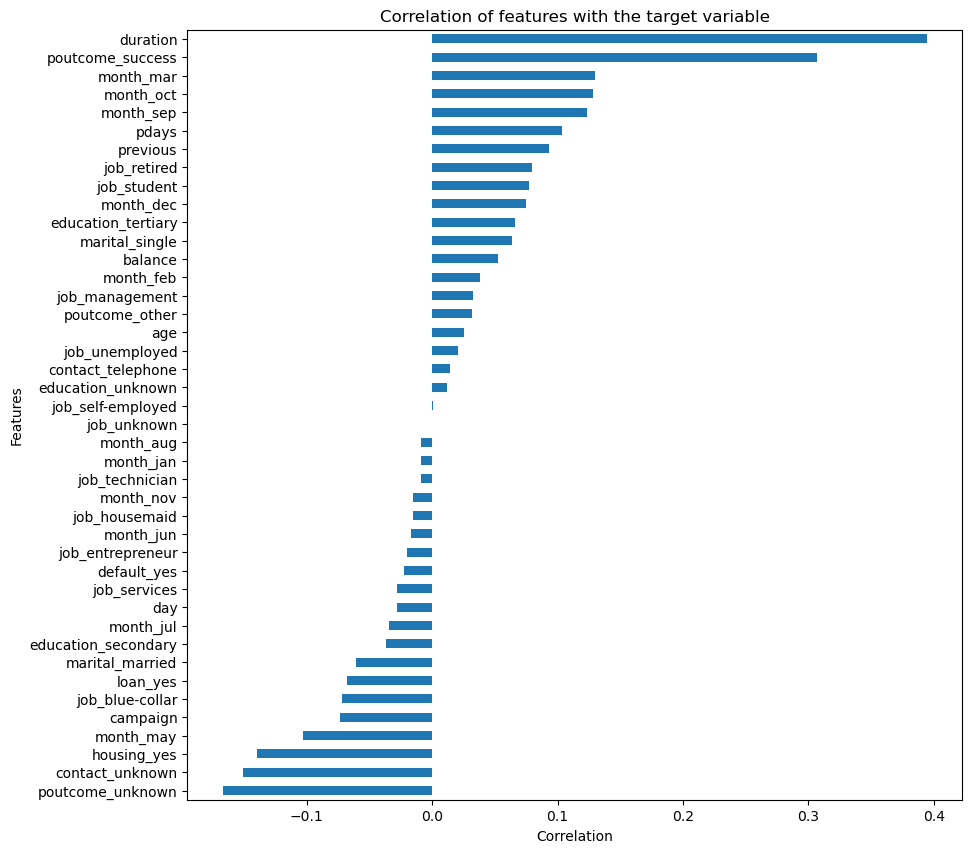

In [25]:
corr = df.corr()
corr_y = corr['y'].sort_values(ascending=True)
corr_y = corr_y.drop('y')
plt.figure(figsize=(10, 10))
corr_y.plot(kind='barh')
plt.title('Correlation of features with the target variable')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

# Ejercicio:
1. Seleccionar aquellas variables que tienen mayor correlación con la variable objetivo y armar un nuevo dataframe
2. Definir un dataset que contenga los datos X, y
3. Separar en conjuntos de entrenamiento y prueba usando una  proporcion 70% 30%
4. Entrenar un modelo de regresión logistica
5. Hacer las predicciones con el conjunto de prueba y calcular metricas
6. Repetir el proceso incluyendo o excluyendo algunas variables